In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration globale des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Bibliothèques importées avec succès!")

Bibliothèques importées avec succès!


In [7]:
# Chargement du dataset
# avec ces colonnes (14) et quelques llignes

df = pd.read_csv('../data/heart_disease_uci.csv')

print("Dataset chargé avec succès!")
print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print(f"\n Aperçu des premières lignes :")
df.head()

Dataset chargé avec succès!
Dimensions : 303 lignes x 14 colonnes

 Aperçu des premières lignes :


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [8]:
# Infos generales sur le dataset

print("=" * 55)
print("TYPES DE DONNÉES ET VALEURS MANQUANTES")
print("=" * 55)
print(df.info())

print("\n" + "=" * 55)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 55)
df.describe().round(2)

TYPES DE DONNÉES ET VALEURS MANQUANTES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB
None

STATISTIQUES DESCRIPTIVES


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.66,4.72,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.93,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


In [9]:
# verification des valeurs manquantes

manquantes = df.isnull().sum()

print("Valeurs manquantes par colonne :")
print(manquantes)
print(f"\n Total valeurs manquantes : {manquantes.sum()}")

if manquantes.sum() == 0:
    print("Le dataset est propre, aucune valeur manquante !")

Valeurs manquantes par colonne :
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

 Total valeurs manquantes : 0
Le dataset est propre, aucune valeur manquante !


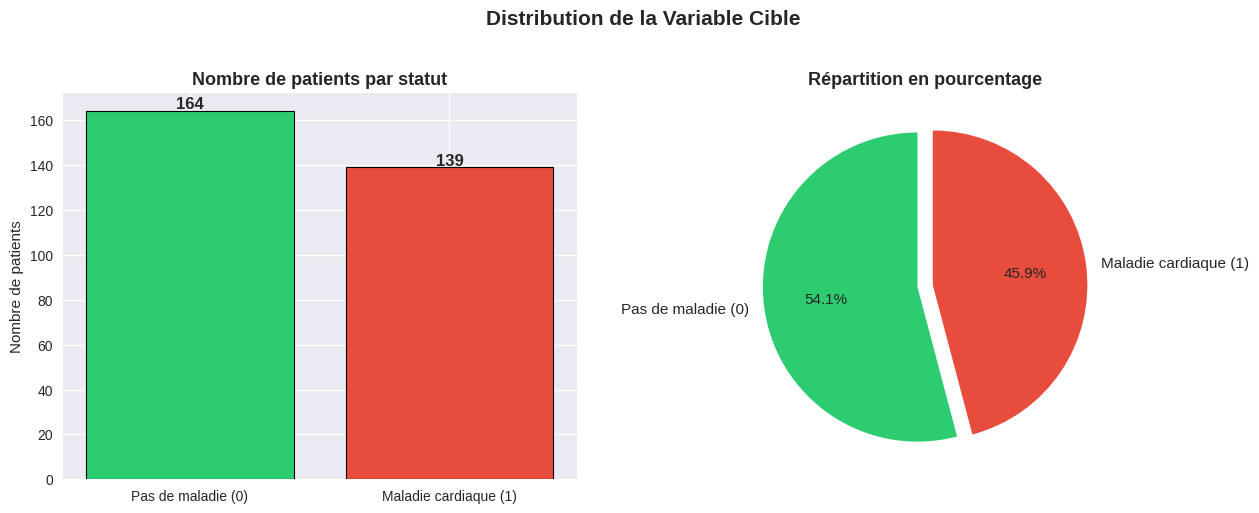

Patients SANS maladie : 164 (54.1%)
Patients AVEC maladie : 139 (45.9%)


In [12]:
# Distribution de la variable cible

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df['target'].value_counts()
labels = ['Pas de maladie (0)', 'Maladie cardiaque (1)']
colors = ['#2ecc71', '#e74c3c']

# --- Graphique 1 : Barres ---
bars = axes[0].bar(labels, counts.values, color=colors, 
                   edgecolor='black', linewidth=0.8)
axes[0].set_title('Nombre de patients par statut', 
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de patients')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 1, str(val),
                 ha='center', fontweight='bold', fontsize=12)

# --- Graphique 2 : Camembert ---
axes[1].pie(counts.values,
            labels=labels,
            colors=colors,
            autopct='%1.1f%%',
            startangle=90,
            explode=(0.05, 0.05),
            textprops={'fontsize': 11})
axes[1].set_title('Répartition en pourcentage', 
                  fontsize=13, fontweight='bold')

plt.suptitle('Distribution de la Variable Cible', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/01_distribution_cible.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Patients SANS maladie : {counts[0]} ({counts[0]/len(df)*100:.1f}%)")
print(f"Patients AVEC maladie : {counts[1]} ({counts[1]/len(df)*100:.1f}%)")

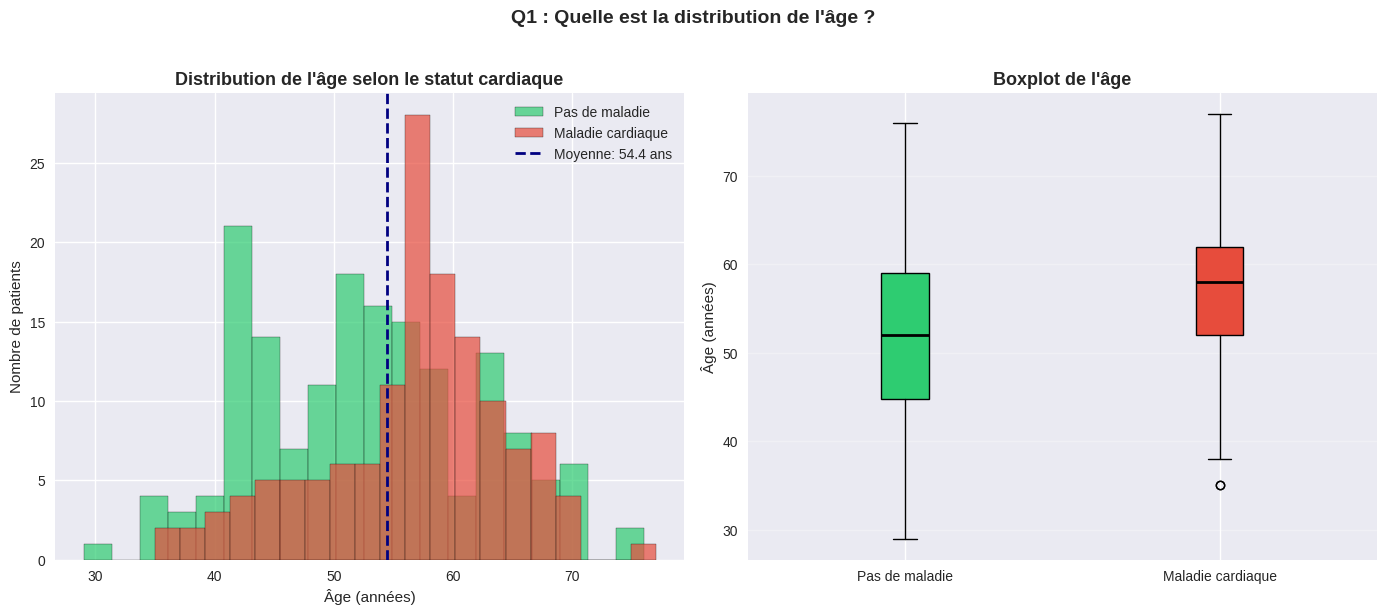

Statistiques d'âge par statut :
        count   mean   std   min    25%   50%   75%   max
target                                                   
0       164.0  52.59  9.51  29.0  44.75  52.0  59.0  76.0
1       139.0  56.63  7.94  35.0  52.00  58.0  62.0  77.0


In [13]:
# Distribution de l'age des individus

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Histogramme ---
axes[0].hist(df[df['target'] == 0]['age'], bins=20, alpha=0.7,
             color='#2ecc71', label='Pas de maladie', edgecolor='black')
axes[0].hist(df[df['target'] == 1]['age'], bins=20, alpha=0.7,
             color='#e74c3c', label='Maladie cardiaque', edgecolor='black')
axes[0].set_title("Distribution de l'âge selon le statut cardiaque",
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel("Âge (années)")
axes[0].set_ylabel("Nombre de patients")
axes[0].legend()
axes[0].axvline(df['age'].mean(), color='navy', linestyle='--',
                linewidth=2, label=f"Moyenne: {df['age'].mean():.1f} ans")
axes[0].legend()

# --- Boxplot ---
data_plot = [df[df['target'] == 0]['age'].values,
             df[df['target'] == 1]['age'].values]
bp = axes[1].boxplot(data_plot,
                     labels=['Pas de maladie', 'Maladie cardiaque'],
                     patch_artist=True, notch=False)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)
axes[1].set_title("Boxplot de l'âge", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Âge (années)")
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("Q1 : Quelle est la distribution de l'âge ?",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/02_distribution_age.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Statistiques d'âge par statut :")
print(df.groupby('target')['age'].describe().round(2))

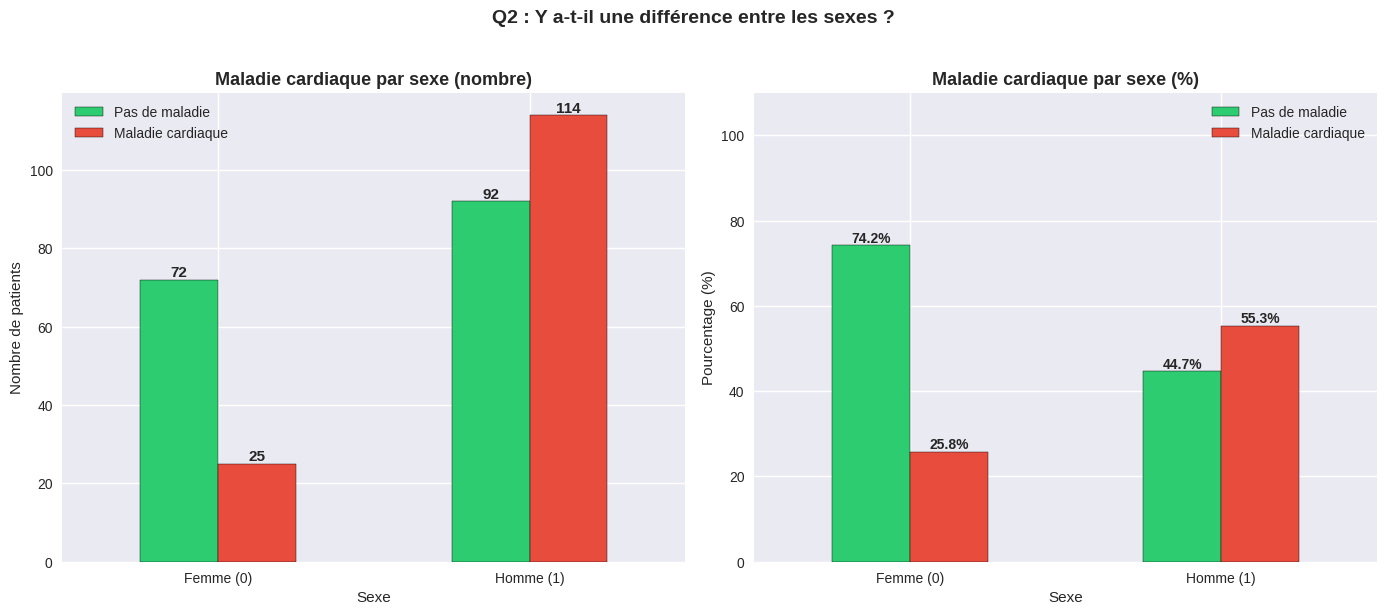

Tableau croisé (nombre) :
           Pas de maladie  Maladie cardiaque
Femme (0)              72                 25
Homme (1)              92                114

 Tableau croisé (pourcentage) :
           Pas de maladie  Maladie cardiaque
Femme (0)            74.2               25.8
Homme (1)            44.7               55.3


In [15]:
# Difference de maladie cardiaque entre les sexes

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cross_sex = pd.crosstab(df['sex'], df['target'])
cross_sex.index = ['Femme (0)', 'Homme (1)']
cross_sex.columns = ['Pas de maladie', 'Maladie cardiaque']

# --- Barres groupées ---
cross_sex.plot(kind='bar', ax=axes[0],
               color=['#2ecc71', '#e74c3c'],
               edgecolor='black', rot=0)
axes[0].set_title('Maladie cardiaque par sexe (nombre)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sexe')
axes[0].set_ylabel('Nombre de patients')
axes[0].legend()
for container in axes[0].containers:
    axes[0].bar_label(container, fontweight='bold', fontsize=11)

# --- Barres empilées en pourcentage ---
cross_pct = cross_sex.div(cross_sex.sum(axis=1), axis=0) * 100
cross_pct.plot(kind='bar', ax=axes[1],
               color=['#2ecc71', '#e74c3c'],
               edgecolor='black', rot=0)
axes[1].set_title('Maladie cardiaque par sexe (%)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sexe')
axes[1].set_ylabel('Pourcentage (%)')
axes[1].legend()
axes[1].set_ylim(0, 110)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', 
                      fontweight='bold', fontsize=10)

plt.suptitle("Q2 : Y a-t-il une différence entre les sexes ?",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/03_maladie_par_sexe.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Tableau croisé (nombre) :")
print(cross_sex)
print("\n Tableau croisé (pourcentage) :")
print(cross_pct.round(1))

KeyError: 4

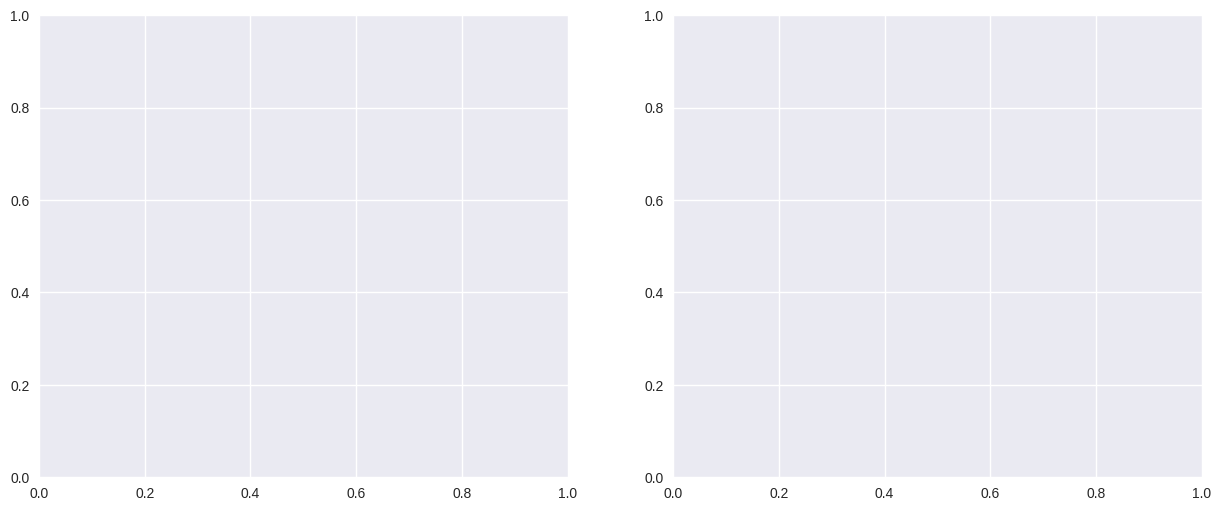

In [16]:
# Type de douleurs 

cp_labels = {
    0: 'Angine\ntypique',
    1: 'Angine\natypique',
    2: 'Douleur non\nangineuse',
    3: 'Asympto-\nmatique'
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cross_cp = pd.crosstab(df['cp'], df['target'])
cross_cp.index = [cp_labels[i] for i in cross_cp.index]
cross_cp.columns = ['Pas de maladie', 'Maladie cardiaque']

# --- Barres groupées ---
cross_cp.plot(kind='bar', ax=axes[0],
              color=['#2ecc71', '#e74c3c'],
              edgecolor='black', rot=0)
axes[0].set_title('Type de douleur thoracique vs Maladie',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Type de douleur thoracique (cp)')
axes[0].set_ylabel('Nombre de patients')
axes[0].legend()
for container in axes[0].containers:
    axes[0].bar_label(container, fontweight='bold')

# --- Heatmap ---
sns.heatmap(pd.crosstab(df['cp'], df['target']),
            annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Pas maladie', 'Maladie'],
            linewidths=1, ax=axes[1],
            cbar_kws={'label': 'Nombre de patients'})
axes[1].set_title('Heatmap : Type de douleur vs Maladie',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Maladie cardiaque (target)')
axes[1].set_ylabel('Type de douleur (cp)')

plt.suptitle("Q3 : Lien entre type de douleur thoracique et maladie cardiaque ?",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/04_douleur_thoracique.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Type de douleur vs Maladie cardiaque :")
print(cross_cp)

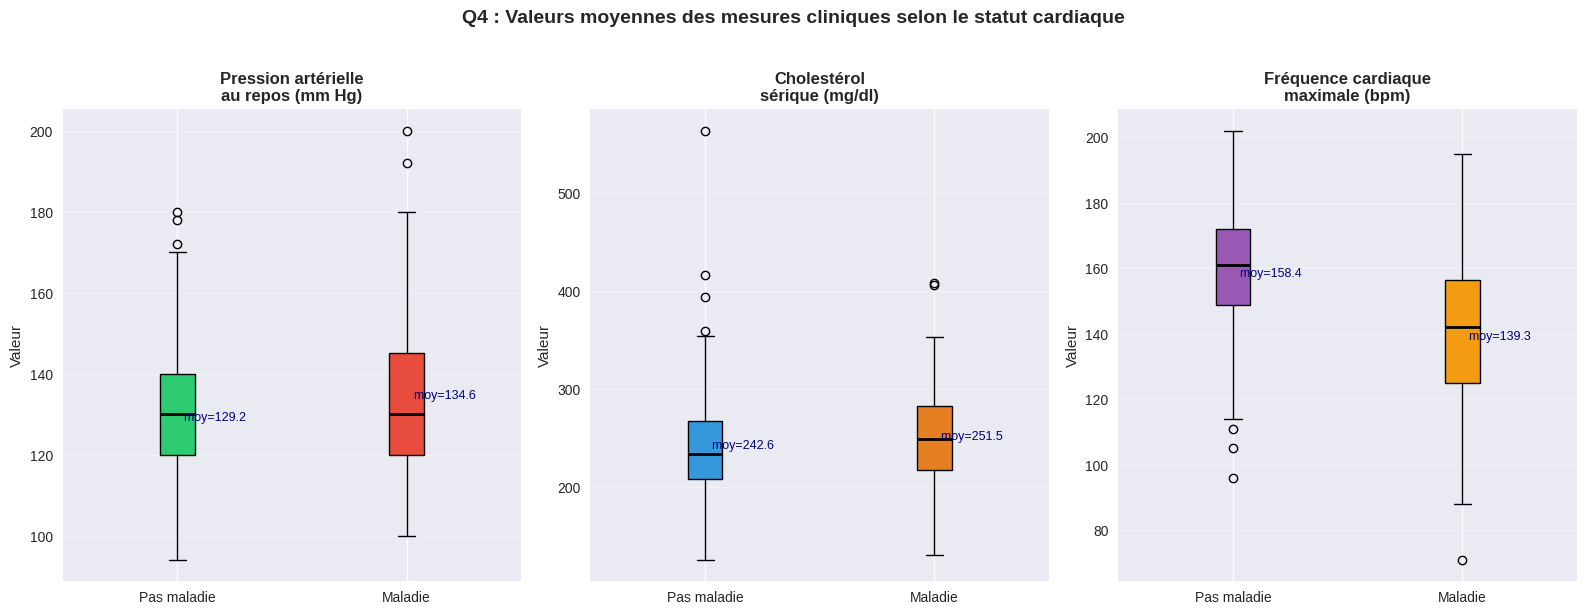

Moyennes par statut cardiaque :
        trestbps    chol  thalach
target                           
0         129.25  242.64   158.38
1         134.57  251.47   139.26


In [17]:

# Valeurs moyennes trestbps, chol, thalach

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

variables = ['trestbps', 'chol', 'thalach']
titres = [
    'Pression artérielle\nau repos (mm Hg)',
    'Cholestérol\nsérique (mg/dl)',
    'Fréquence cardiaque\nmaximale (bpm)'
]
colors_box = [['#2ecc71', '#e74c3c'],
              ['#3498db', '#e67e22'],
              ['#9b59b6', '#f39c12']]

for idx, (var, titre, cols) in enumerate(zip(variables, titres, colors_box)):
    data = [df[df['target'] == 0][var].values,
            df[df['target'] == 1][var].values]
    bp = axes[idx].boxplot(data,
                           labels=['Pas maladie', 'Maladie'],
                           patch_artist=True)
    bp['boxes'][0].set_facecolor(cols[0])
    bp['boxes'][1].set_facecolor(cols[1])
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)
    axes[idx].set_title(titre, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Valeur')
    axes[idx].grid(axis='y', alpha=0.3)

    # Afficher la moyenne
    for i, d in enumerate(data):
        axes[idx].text(i + 1, np.mean(d),
                       f'  moy={np.mean(d):.1f}',
                       va='center', fontsize=9, color='navy')

plt.suptitle("Q4 : Valeurs moyennes des mesures cliniques selon le statut cardiaque",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/05_mesures_cliniques.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Moyennes par statut cardiaque :")
print(df.groupby('target')[['trestbps', 'chol', 'thalach']].mean().round(2))

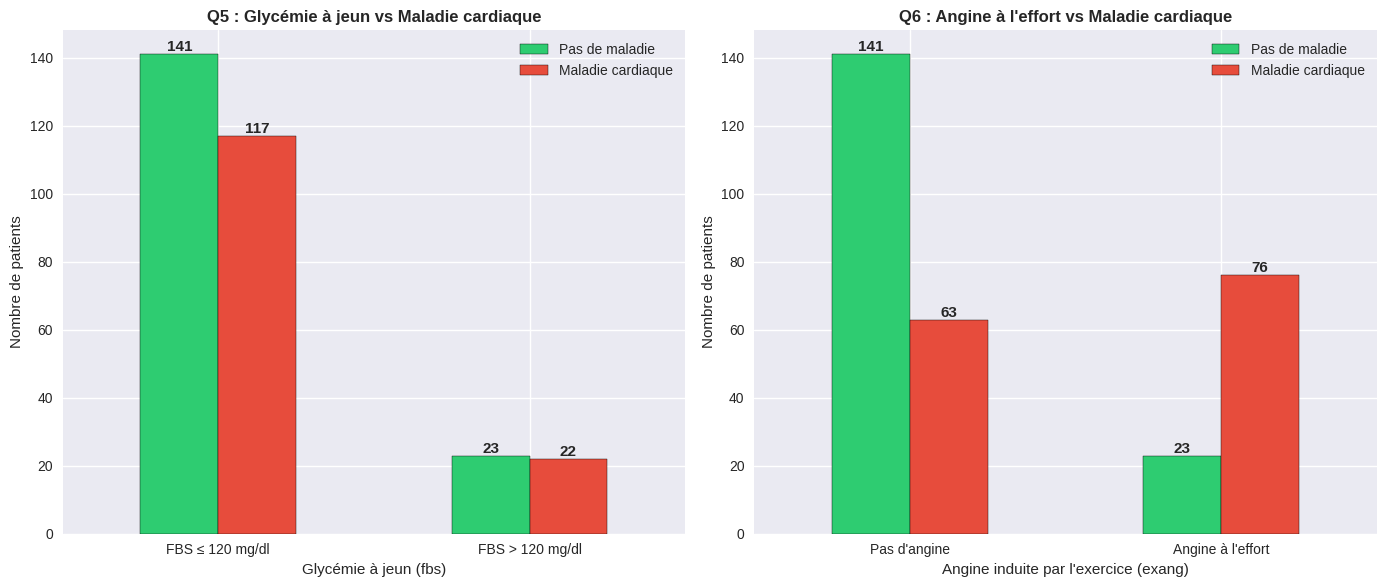

Q5 - Glycémie à jeun vs Maladie :
                 Pas de maladie  Maladie cardiaque
FBS ≤ 120 mg/dl             141                117
FBS > 120 mg/dl              23                 22

 Q6 - Angine à l'effort vs Maladie :
                   Pas de maladie  Maladie cardiaque
Pas d'angine                  141                 63
Angine à l'effort              23                 76


In [18]:

# QUESTION 5 : Glycémie à jeun (fbs) et maladie cardiaque ?
# QUESTION 6 : Angine à l'effort (exang) et maladie cardiaque ?

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Q5 : FBS ---
cross_fbs = pd.crosstab(df['fbs'], df['target'])
cross_fbs.index = ['FBS ≤ 120 mg/dl', 'FBS > 120 mg/dl']
cross_fbs.columns = ['Pas de maladie', 'Maladie cardiaque']
cross_fbs.plot(kind='bar', ax=axes[0],
               color=['#2ecc71', '#e74c3c'],
               edgecolor='black', rot=0)
axes[0].set_title("Q5 : Glycémie à jeun vs Maladie cardiaque",
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Glycémie à jeun (fbs)')
axes[0].set_ylabel('Nombre de patients')
axes[0].legend()
for container in axes[0].containers:
    axes[0].bar_label(container, fontweight='bold', fontsize=11)

# --- Q6 : EXANG ---
cross_exang = pd.crosstab(df['exang'], df['target'])
cross_exang.index = ["Pas d'angine", "Angine à l'effort"]
cross_exang.columns = ['Pas de maladie', 'Maladie cardiaque']
cross_exang.plot(kind='bar', ax=axes[1],
                 color=['#2ecc71', '#e74c3c'],
                 edgecolor='black', rot=0)
axes[1].set_title("Q6 : Angine à l'effort vs Maladie cardiaque",
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel("Angine induite par l'exercice (exang)")
axes[1].set_ylabel('Nombre de patients')
axes[1].legend()
for container in axes[1].containers:
    axes[1].bar_label(container, fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../data/06_fbs_exang.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Q5 - Glycémie à jeun vs Maladie :")
print(cross_fbs)
print("\n Q6 - Angine à l'effort vs Maladie :")
print(cross_exang)

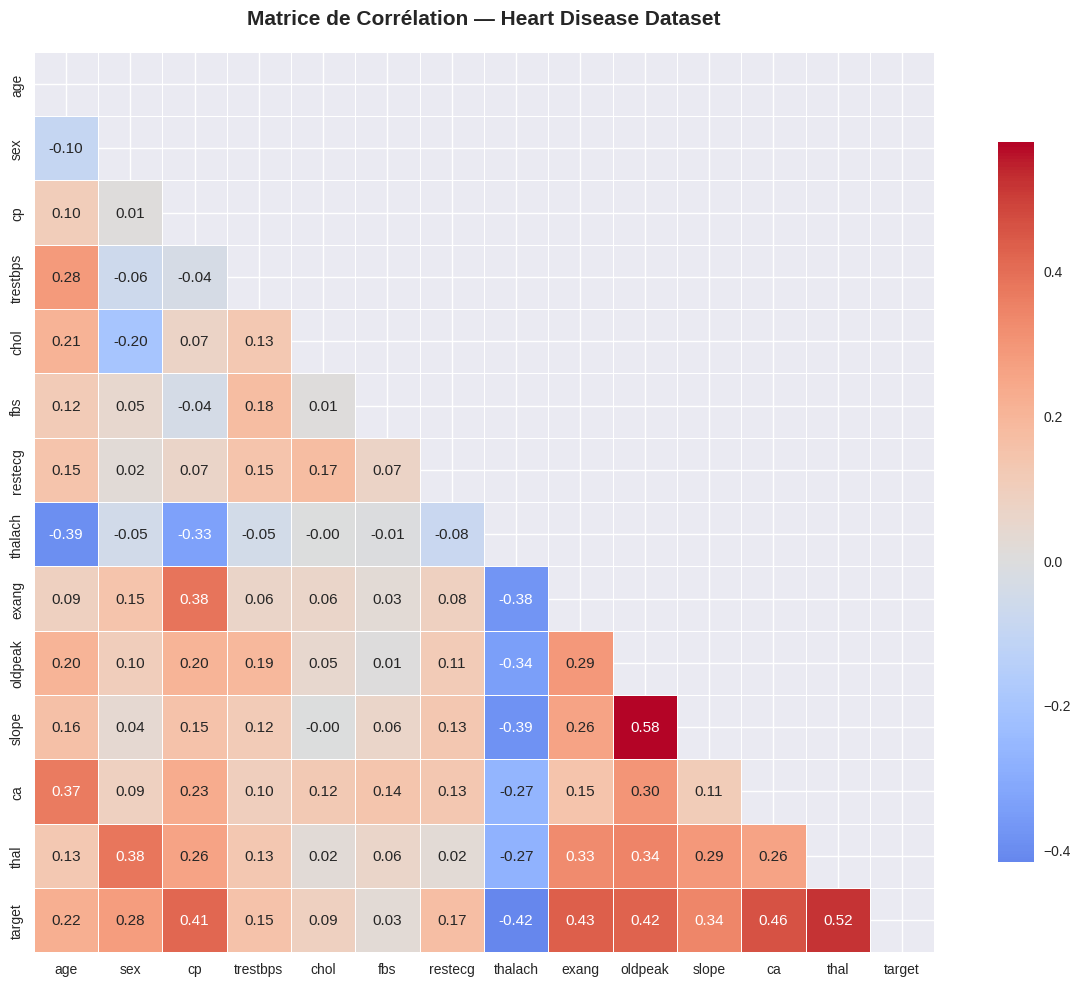

Corrélations avec la variable cible 'target' :
target      1.000
thal        0.522
ca          0.460
exang       0.432
oldpeak     0.425
cp          0.414
slope       0.339
sex         0.277
age         0.223
restecg     0.169
trestbps    0.151
chol        0.085
fbs         0.025
thalach    -0.417
Name: target, dtype: float64


In [19]:

# MATRICE DE CORRÉLATION

plt.figure(figsize=(13, 10))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Matrice de Corrélation — Heart Disease Dataset',
          fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../data/07_correlation_matrix.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Corrélations avec la variable cible 'target' :")
print(corr['target'].sort_values(ascending=False).round(3))

In [21]:

# PRÉPARATION DES DONNÉES POUR LE MACHINE LEARNING

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Séparation features / cible
X = df.drop('target', axis=1)
y = df['target']

print(f" Features (X) : {X.shape}")
print(f" Cible    (y) : {y.shape}")
print(f"\n Colonnes utilisées comme features :")
for col in X.columns:
    print(f"   • {col}")

# Division 80% train / 20% test
# stratify=y : garde la même proportion malade/sain dans les deux ensembles
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n Division des données :")
print(f"   • Entraînement : {X_train.shape[0]} patients")
print(f"   • Test         : {X_test.shape[0]} patients")

# Normalisation (obligatoire pour KNN et SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n Données normalisées avec StandardScaler !")

 Features (X) : (303, 13)
 Cible    (y) : (303,)

 Colonnes utilisées comme features :
   • age
   • sex
   • cp
   • trestbps
   • chol
   • fbs
   • restecg
   • thalach
   • exang
   • oldpeak
   • slope
   • ca
   • thal

 Division des données :
   • Entraînement : 242 patients
   • Test         : 61 patients

 Données normalisées avec StandardScaler !


In [22]:

# DÉFINITION DES 6 ALGORITHMES DE CLASSIFICATION

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

modeles = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost'            : AdaBoostClassifier(n_estimators=100, random_state=42)
}

print("Les 6 modèles sont définis et prêts :")
for nom in modeles:
    print(f"   • {nom}")

Les 6 modèles sont définis et prêts :
   • Logistic Regression
   • K-Nearest Neighbors
   • Support Vector Machine
   • Decision Tree
   • Random Forest
   • AdaBoost


In [26]:

# ENTRAÎNEMENT ET ÉVALUATION DES 6 MODÈLES

from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              roc_auc_score, confusion_matrix,
                              roc_curve, classification_report)

resultats       = {}
modeles_entraines = {}

print("Entraînement en cours...\n")
print("=" * 60)

for nom, modele in modeles.items():
    print(f"{nom}...")

    modele.fit(X_train_scaled, y_train)
    y_pred       = modele.predict(X_test_scaled)
    y_pred_proba = modele.predict_proba(X_test_scaled)[:, 1]

    resultats[nom] = {
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Précision': round(precision_score(y_test, y_pred), 4),
        'Rappel'   : round(recall_score(y_test, y_pred), 4),
        'F1-Score' : round(f1_score(y_test, y_pred), 4),
        'AUC-ROC'  : round(roc_auc_score(y_test, y_pred_proba), 4)
    }

    modeles_entraines[nom] = modele
    print(f"   Accuracy={resultats[nom]['Accuracy']:.4f} | "
          f"AUC-ROC={resultats[nom]['AUC-ROC']:.4f}")

print("\n" + "=" * 60)
print("Tous les modèles sont entraînés !")

Entraînement en cours...

Logistic Regression...
   Accuracy=0.8689 | AUC-ROC=0.9513
K-Nearest Neighbors...
   Accuracy=0.8852 | AUC-ROC=0.9232
Support Vector Machine...
   Accuracy=0.8525 | AUC-ROC=0.9437
Decision Tree...
   Accuracy=0.7705 | AUC-ROC=0.8030
Random Forest...
   Accuracy=0.8852 | AUC-ROC=0.9513
AdaBoost...
   Accuracy=0.8525 | AUC-ROC=0.9102

Tous les modèles sont entraînés !


In [27]:

# TABLEAU COMPARATIF DES PERFORMANCES

df_resultats = pd.DataFrame(resultats).T
df_resultats = df_resultats.sort_values('AUC-ROC', ascending=False)

print("=" * 68)
print("   COMPARAISON DES 6 ALGORITHMES DE CLASSIFICATION")
print("=" * 68)
print(df_resultats.to_string())
print("=" * 68)

# Meilleur modèle
meilleur = df_resultats['AUC-ROC'].idxmax()
print(f"\n Meilleur modèle (AUC-ROC) : {meilleur}")
print(f"   → AUC-ROC  : {df_resultats.loc[meilleur,'AUC-ROC']:.4f}")
print(f"   → Accuracy : {df_resultats.loc[meilleur,'Accuracy']:.4f}")
print(f"   → F1-Score : {df_resultats.loc[meilleur,'F1-Score']:.4f}")

   COMPARAISON DES 6 ALGORITHMES DE CLASSIFICATION
                        Accuracy  Précision  Rappel  F1-Score  AUC-ROC
Logistic Regression       0.8689     0.8125  0.9286    0.8667   0.9513
Random Forest             0.8852     0.8182  0.9643    0.8852   0.9513
Support Vector Machine    0.8525     0.8065  0.8929    0.8475   0.9437
K-Nearest Neighbors       0.8852     0.8000  1.0000    0.8889   0.9232
AdaBoost                  0.8525     0.7714  0.9643    0.8571   0.9102
Decision Tree             0.7705     0.7059  0.8571    0.7742   0.8030

 Meilleur modèle (AUC-ROC) : Logistic Regression
   → AUC-ROC  : 0.9513
   → Accuracy : 0.8689
   → F1-Score : 0.8667


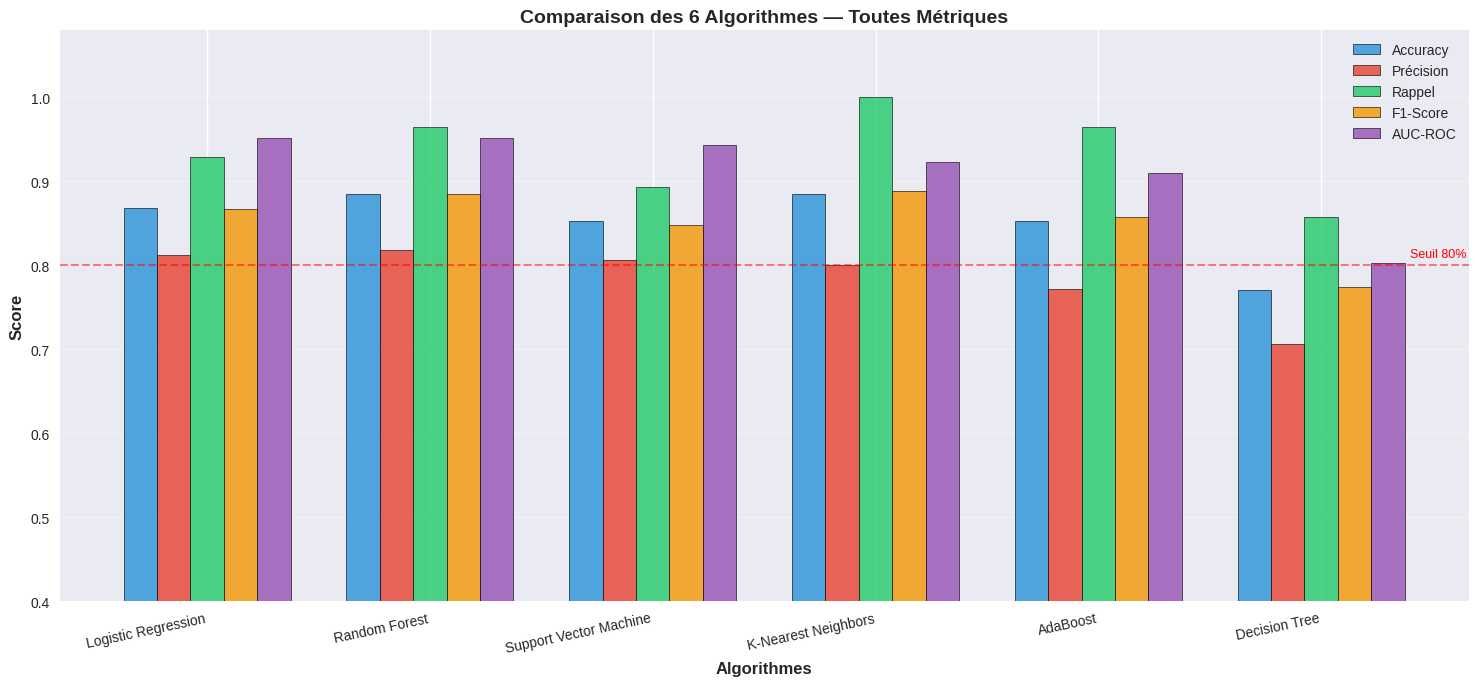

In [28]:

# VISUALISATION : COMPARAISON DE TOUTES LES MÉTRIQUES

metriques = ['Accuracy', 'Précision', 'Rappel', 'F1-Score', 'AUC-ROC']
colors_m  = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

x     = np.arange(len(df_resultats))
width = 0.15

fig, ax = plt.subplots(figsize=(15, 7))

for i, (metrique, color) in enumerate(zip(metriques, colors_m)):
    bars = ax.bar(x + i * width,
                  df_resultats[metrique],
                  width,
                  label=metrique,
                  color=color,
                  alpha=0.85,
                  edgecolor='black',
                  linewidth=0.5)

ax.set_xlabel('Algorithmes', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Comparaison des 6 Algorithmes — Toutes Métriques',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(df_resultats.index, rotation=12, ha='right', fontsize=10)
ax.legend(fontsize=10)
ax.set_ylim(0.4, 1.08)
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
ax.text(len(x) - 0.3, 0.81, 'Seuil 80%', color='red', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/08_comparaison_modeles.png', 
            dpi=150, bbox_inches='tight')
plt.show()

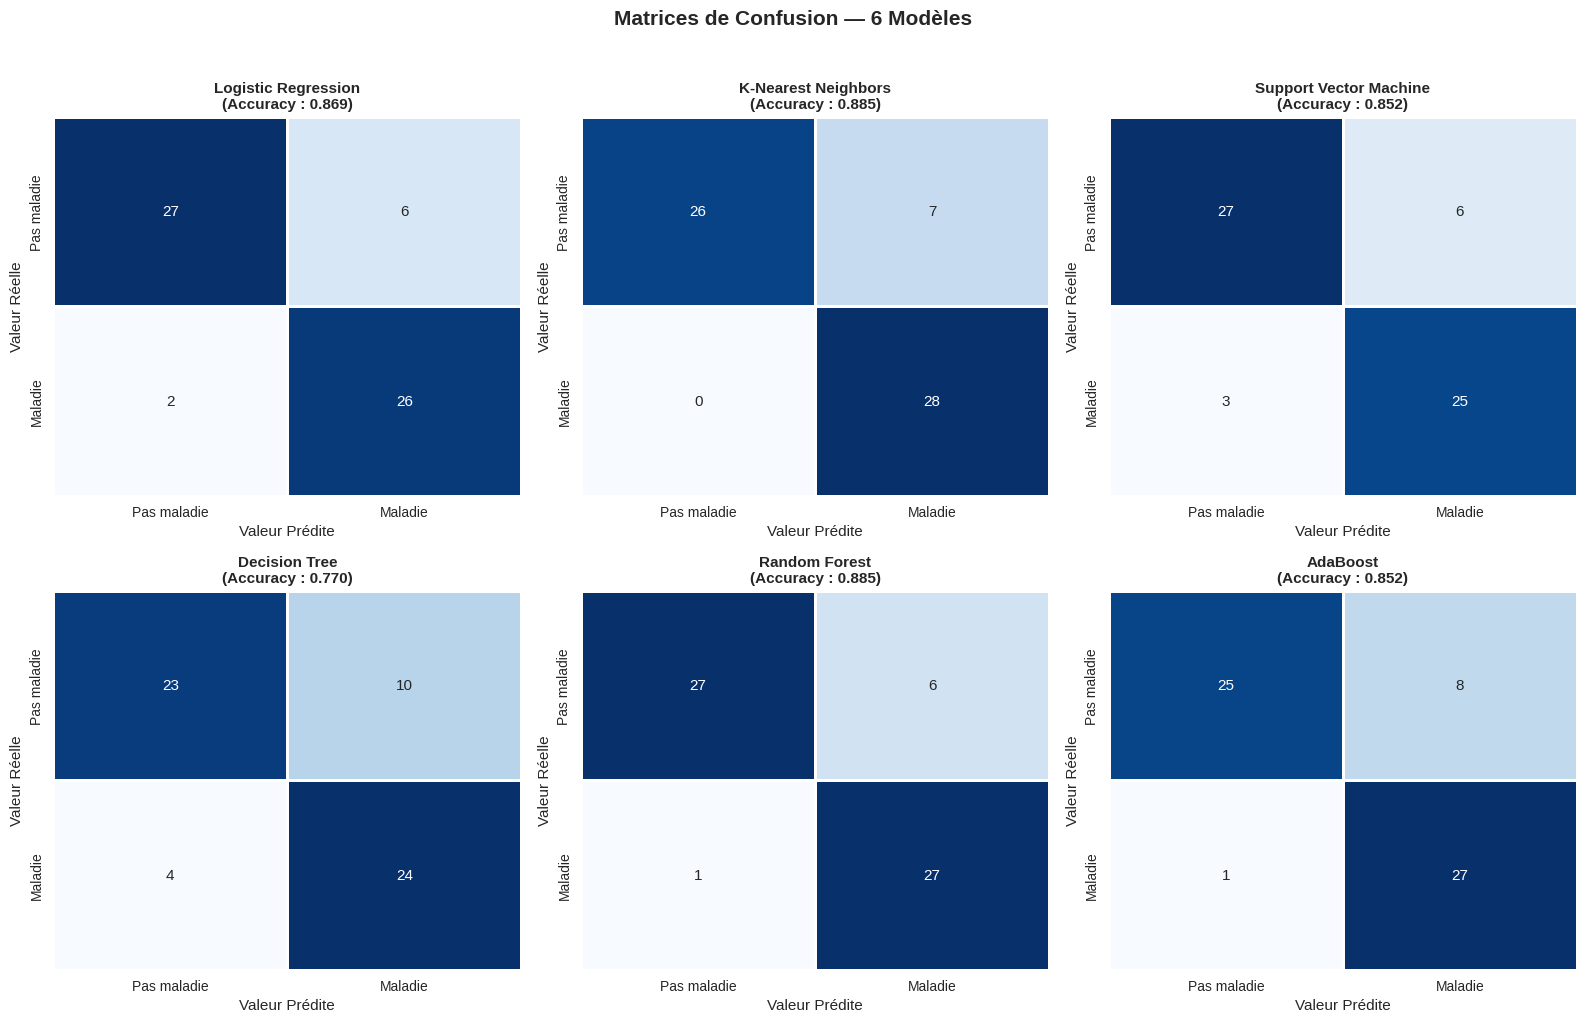

In [29]:

# MATRICES DE CONFUSION — TOUS LES MODÈLES

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (nom, modele) in enumerate(modeles_entraines.items()):
    y_pred = modele.predict(X_test_scaled)
    cm     = confusion_matrix(y_test, y_pred)
    acc    = accuracy_score(y_test, y_pred)

    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=['Pas maladie', 'Maladie'],
                yticklabels=['Pas maladie', 'Maladie'],
                ax=axes[idx],
                linewidths=1,
                cbar=False)

    axes[idx].set_title(f'{nom}\n(Accuracy : {acc:.3f})',
                        fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Valeur Prédite')
    axes[idx].set_ylabel('Valeur Réelle')

plt.suptitle('Matrices de Confusion — 6 Modèles',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/09_matrices_confusion.png', 
            dpi=150, bbox_inches='tight')
plt.show()

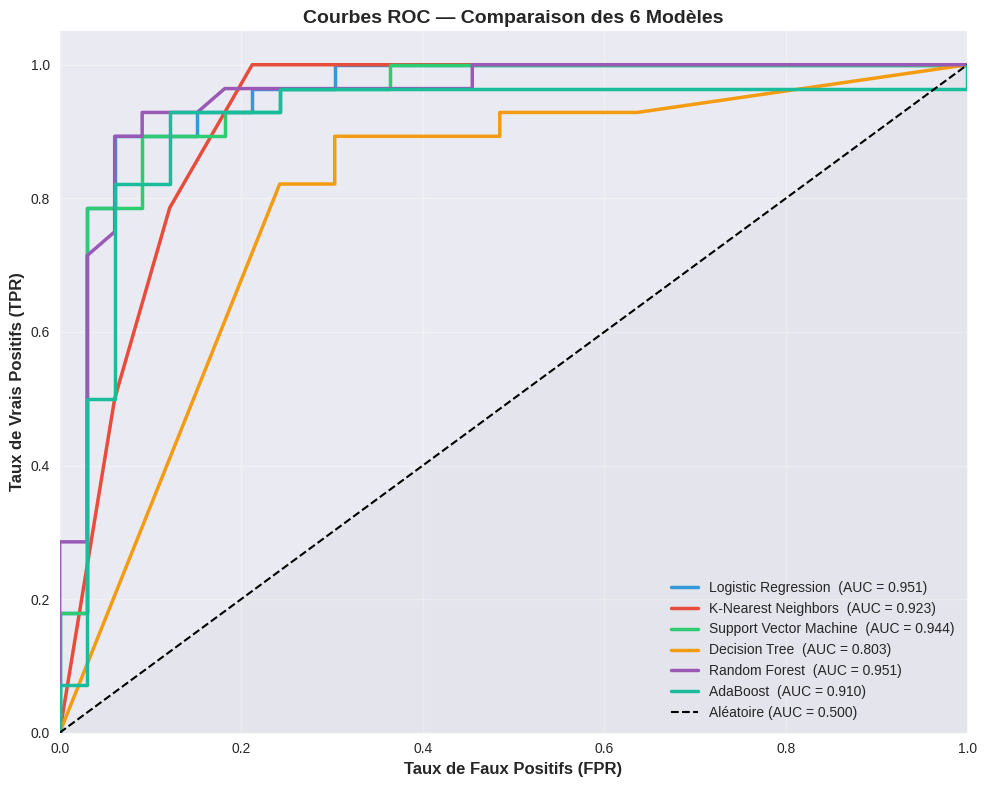

 Courbes ROC générées !


In [30]:

# COURBES ROC — COMPARAISON VISUELLE

colors_roc = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c']

plt.figure(figsize=(10, 8))

for (nom, modele), color in zip(modeles_entraines.items(), colors_roc):
    y_proba      = modele.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _  = roc_curve(y_test, y_proba)
    auc          = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=color, lw=2.5,
             label=f'{nom}  (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Aléatoire (AUC = 0.500)')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12, fontweight='bold')
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12, fontweight='bold')
plt.title('Courbes ROC — Comparaison des 6 Modèles',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/10_courbes_roc.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print(" Courbes ROC générées !")

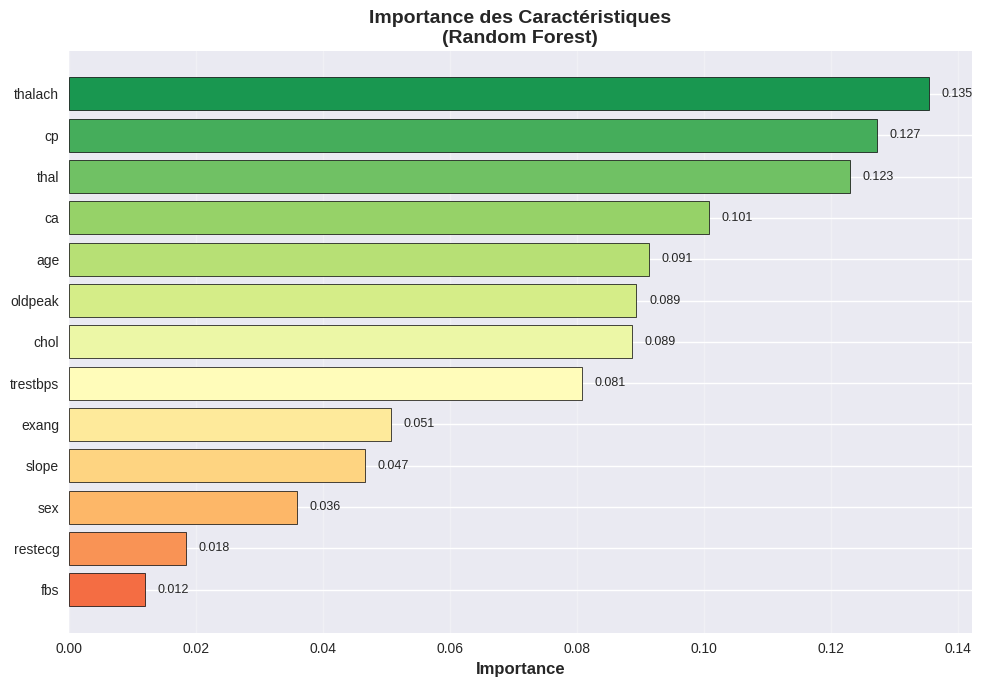

Top 5 des caractéristiques les plus importantes :
Feature  Importance
thalach    0.135404
     cp    0.127163
   thal    0.122940
     ca    0.100811
    age    0.091327


In [31]:

# IMPORTANCE DES CARACTÉRISTIQUES (Random Forest)

rf = modeles_entraines['Random Forest']

feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp)))

plt.figure(figsize=(10, 7))
bars = plt.barh(feat_imp['Feature'], feat_imp['Importance'],
                color=colors_imp, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, feat_imp['Importance']):
    plt.text(val + 0.002,
             bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=9)

plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.title("Importance des Caractéristiques\n(Random Forest)",
          fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/11_feature_importance.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 des caractéristiques les plus importantes :")
print(feat_imp.sort_values('Importance', ascending=False).head(5).to_string(index=False))

In [32]:

# SAUVEGARDE DES MODÈLES ENTRAÎNÉS ET DES RÉSULTATS

import pickle
import os

os.makedirs('../data/models', exist_ok=True)

# Sauvegarde de chaque modèle
for nom, modele in modeles_entraines.items():
    nom_fichier = nom.replace(' ', '_').replace('-', '_').lower()
    chemin = f'../data/models/{nom_fichier}.pkl'
    with open(chemin, 'wb') as f:
        pickle.dump(modele, f)
    print(f" Sauvegardé : {chemin}")

# Sauvegarde du scaler
with open('../data/models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(" Sauvegardé : ../data/models/scaler.pkl")

# Sauvegarde du tableau des résultats
df_resultats.to_csv('../data/resultats_modeles.csv')
print(" Sauvegardé : ../data/resultats_modeles.csv")

print("\n Fichiers dans data/models/ :")
for f in sorted(os.listdir('../data/models')):
    print(f"   • {f}")

 Sauvegardé : ../data/models/logistic_regression.pkl
 Sauvegardé : ../data/models/k_nearest_neighbors.pkl
 Sauvegardé : ../data/models/support_vector_machine.pkl
 Sauvegardé : ../data/models/decision_tree.pkl
 Sauvegardé : ../data/models/random_forest.pkl
 Sauvegardé : ../data/models/adaboost.pkl
 Sauvegardé : ../data/models/scaler.pkl
 Sauvegardé : ../data/resultats_modeles.csv

 Fichiers dans data/models/ :
   • adaboost.pkl
   • decision_tree.pkl
   • k_nearest_neighbors.pkl
   • logistic_regression.pkl
   • random_forest.pkl
   • scaler.pkl
   • support_vector_machine.pkl


In [34]:

# CONCLUSION GÉNÉRALE

print("=" * 65)
print("         CONCLUSION FINALE DE L'ANALYSE")
print("=" * 65)

print("\n TABLEAU FINAL DES PERFORMANCES (trié par AUC-ROC) :")
print(df_resultats.to_string())

meilleur_auc = df_resultats['AUC-ROC'].idxmax()
meilleur_acc = df_resultats['Accuracy'].idxmax()
meilleur_f1  = df_resultats['F1-Score'].idxmax()

print(f"""
Meilleur AUC-ROC  : {meilleur_auc}
   → {df_resultats.loc[meilleur_auc,'AUC-ROC']:.4f}

Meilleur Accuracy : {meilleur_acc}
   → {df_resultats.loc[meilleur_acc,'Accuracy']:.4f}

Meilleur F1-Score : {meilleur_f1}
   → {df_resultats.loc[meilleur_f1,'F1-Score']:.4f}

RÉSUMÉ :
   • Dataset     : Heart Disease UCI (303 patients, 13 features)
   • Train/Test  : 80% / 20% (stratifié)
   • Normalisation : StandardScaler

   • Top 3 features (Random Forest) :
""")

top3 = feat_imp.sort_values('Importance', ascending=False).head(3)
for _, row in top3.iterrows():
    print(f"     → {row['Feature']} ({row['Importance']:.3f})")

print("\n" + "=" * 65)
print("Analyse complète !")
print("=" * 65)

         CONCLUSION FINALE DE L'ANALYSE

 TABLEAU FINAL DES PERFORMANCES (trié par AUC-ROC) :
                        Accuracy  Précision  Rappel  F1-Score  AUC-ROC
Logistic Regression       0.8689     0.8125  0.9286    0.8667   0.9513
Random Forest             0.8852     0.8182  0.9643    0.8852   0.9513
Support Vector Machine    0.8525     0.8065  0.8929    0.8475   0.9437
K-Nearest Neighbors       0.8852     0.8000  1.0000    0.8889   0.9232
AdaBoost                  0.8525     0.7714  0.9643    0.8571   0.9102
Decision Tree             0.7705     0.7059  0.8571    0.7742   0.8030

Meilleur AUC-ROC  : Logistic Regression
   → 0.9513

Meilleur Accuracy : Random Forest
   → 0.8852

Meilleur F1-Score : K-Nearest Neighbors
   → 0.8889

RÉSUMÉ :
   • Dataset     : Heart Disease UCI (303 patients, 13 features)
   • Train/Test  : 80% / 20% (stratifié)
   • Normalisation : StandardScaler

   • Top 3 features (Random Forest) :

     → thalach (0.135)
     → cp (0.127)
     → thal (0.123)

An